# 1. Modifica delle importazioni

In [ ]:
# Importazione  librerie
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Importazione di VGG16 e delle sue funzioni specifiche
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

print(import_status := "Librerie caricate correttamente con VGG16!")

Librerie caricate correttamente con VGG16!


# 2. Cambio del modello

In [ ]:
# Istanza del modello VGG16 
print("Caricamento di VGG16 in corso...")
modello_vgg16 = VGG16(weights='imagenet', include_top=True)
print("Modello VGG16 caricato con successo!")

Caricamento di VGG16 in corso...
553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Modello VGG16 caricato con successo!


# 3. Cambio dell'immagine

In [ ]:
# --- CODICE AGGIUNTO PER EVITARE ERRORE 403 ---

import urllib.request
opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')]
urllib.request.install_opener(opener)

# ------------------------------------------------------

# Sostituzione dell'URL dell'immagine (Elefante)
IMMAGINE_URL = "https://upload.wikimedia.org/wikipedia/commons/3/37/African_Bush_Elephant.jpg"

# Dowload dell'immagine temporanea sul sistema
path_immagine = tf.keras.utils.get_file("elefante_test.jpg", IMMAGINE_URL)
print(f"Immagine scaricata e salvata in: {path_immagine}")

4783815/4783815 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Immagine scaricata e salvata in: C:\Users\chian\.keras\datasets\elefante_test.jpg


# 4. Espansione dei Risultati Nella funzione di classificazione

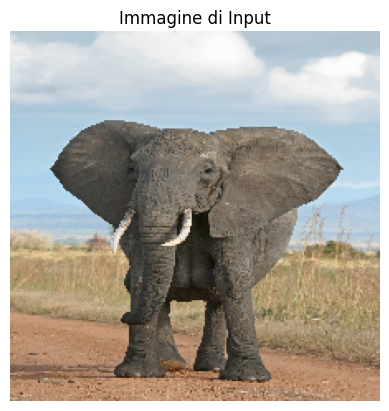

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

--- TOP-5 PREDIZIONI VGG16 ---
1. African Elephant: 85.18%
2. Tusker: 13.99%
3. Indian Elephant: 0.82%
4. Triceratops: 0.01%
5. Warthog: 0.00%


In [6]:
# Preprocessing, Predizione e Visualizzazione

# Caricamento dell'immgaine con il formato ricchiesto 24x24 (224x224)
img = image.load_img(path_immagine, target_size=(224, 224))

# Mostriamo l'immagine a schermo per verifica visiva
plt.imshow(img)
plt.axis('off')
plt.title("Immagine di Input")
plt.show()

# 2. Preprocessing matematico
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0) # Diventa (1, 224, 224, 3)
x = preprocess_input(x)       # Sottrazione della media dei canali ImageNet

# 3. Predizione
predizioni = modello_vgg16.predict(x)

# 4. Decodifica dei risultati: impostiamo top=5 invece di 3
risultati_top5 = decode_predictions(predizioni, top=5)[0]

# 5. Stampa dei risultati a video
print("\n--- TOP-5 PREDIZIONI VGG16 ---")
for i, (id_classe, nome_classe, probabilita) in enumerate(risultati_top5):
    percentuale = probabilita * 100
    print(f"{i+1}. {nome_classe.replace('_', ' ').title()}: {percentuale:.2f}%")

# 5. Verifica dei risultati

1. Il file di download supera i 500 MB
2. Il codice non crasha
3. Le predizioni sono sensate (African Elephant all'85,18%)
4. Vengono stampate 5 righe di risultati